In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install soccerplots

from soccerplots.radar_chart import Radar

In [ ]:
#Read in the Data

df =pd.read_csv('PLayers.csv')

In [ ]:
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,Playing Time MP,Playing Time Starts,Playing Time Min,...,Performance Fld,Performance Off,Performance Crs,Performance Int,Performance TklW,Performance PKwon,Performance PKcon,Performance OG,Competition,Season
0,1.0,Dickson Abiama,ng NGA,FW,Greuther Fürth,24.0,1998.0,13.0,5.0,533.0,...,6.0,1.0,6.0,2.0,1.0,0.0,0.0,0.0,2. Bundesliga,2023-2024
1,3.0,Ragnar Ache,de GER,FW,Kaiserslautern,25.0,1998.0,26.0,22.0,1783.0,...,28.0,13.0,6.0,2.0,3.0,0.0,0.0,0.0,2. Bundesliga,2023-2024
2,4.0,Aremu Afeez,ng NGA,MF,Kaiserslautern,23.0,1999.0,5.0,0.0,56.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2. Bundesliga,2023-2024
3,5.0,Oladapo Afolayan,eng ENG,"FW,MF",St. Pauli,25.0,1998.0,31.0,27.0,2201.0,...,66.0,13.0,78.0,7.0,15.0,0.0,0.0,0.0,2. Bundesliga,2023-2024
4,6.0,Nikolas Agrafiotis,nl NED,FW,Wehen,23.0,2000.0,12.0,5.0,434.0,...,1.0,4.0,4.0,1.0,2.0,0.0,0.0,0.0,2. Bundesliga,2023-2024


In [ ]:
df = pd.read_csv('radars.csv')

In [ ]:
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,Patrick van Aanholt\Patrick-van-Aanholt,nl NED,DF,Crystal Palace,30-185,1990,13.7,0,15,...,20.6,3,0,0,0.8,0.8,0.05,-0.8,-0.8,Matches
1,2,Tammy Abraham\Tammy-Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,31,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
2,3,Che Adams\Che-Adams,eng ENG,FW,Southampton,24-232,1996,21.2,4,40,...,13.5,0,0,0,5.3,5.3,0.13,-1.3,-1.3,Matches
3,4,Tosin Adarabioyo\Tosin-Adarabioyo,eng ENG,DF,Fulham,23-159,1997,22.0,0,17,...,9.0,0,0,0,0.9,0.9,0.06,-0.9,-0.9,Matches
4,5,Adrián\Adrian,es ESP,GK,Liverpool,34-058,1987,3.0,0,0,...,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches


In [ ]:
df['Player'] = df['Player'].str.split('\\', expand = True)[0]

In [ ]:
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,Patrick van Aanholt,nl NED,DF,Crystal Palace,30-185,1990,13.7,0,15,...,20.6,3,0,0,0.8,0.8,0.05,-0.8,-0.8,Matches
1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,31,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
2,3,Che Adams,eng ENG,FW,Southampton,24-232,1996,21.2,4,40,...,13.5,0,0,0,5.3,5.3,0.13,-1.3,-1.3,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Fulham,23-159,1997,22.0,0,17,...,9.0,0,0,0,0.9,0.9,0.06,-0.9,-0.9,Matches
4,5,Adrián,es ESP,GK,Liverpool,34-058,1987,3.0,0,0,...,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches


In [ ]:
df = df[(df['Player']=='Tammy Abraham') | (df['Player']== 'Timo Werner')].reset_index()

In [ ]:
df

,index,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
1,481,482,Timo Werner,de GER,FW,Chelsea,24-361,1996,20.5,5,...,13.7,0,0,0,8.4,8.4,0.15,-3.4,-3.4,Matches


In [ ]:
df = df.drop(['index','Rk','Nation','Pos','Squad','Age','Born','90s','FK','PK','PKatt','Matches'], axis = 1)

In [ ]:
df

,Player,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,Dist,xG,npxG,npxG/Sh,G-xG,np:G-xG
0,Tammy Abraham,6,31,13,41.9,2.73,1.15,0.19,0.46,9.9,5.6,5.6,0.18,0.4,0.4
1,Timo Werner,5,55,21,38.2,2.69,1.03,0.09,0.24,13.7,8.4,8.4,0.15,-3.4,-3.4


In [ ]:
#Get Parameters

params = list(df.columns)
params = params[1:]
params

['Gls',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'Dist',
 'xG',
 'npxG',
 'npxG/Sh',
 'G-xG',
 'np:G-xG']

In [ ]:
#Add Ranges to List of Tuple Pairs

ranges = []
a_values = []
b_values = []

for x in params:
  a = min(df[params][x])
  a = a -(a*.25)

  b = max(df[params][x])
  b = b + (b*.25)

  ranges.append((a,b))

for x in range(len(df['Player'])):
  if df ['Player'][x] == 'Tammy Abraham':
    a_values = df.iloc[x].values.tolist()
  if df['Player'][x] == 'Timo Werner':
    b_values = df.iloc[x].values.tolist()

a_values = a_values[1:]
b_values = b_values[1:]

values = [a_values,b_values]

In [ ]:
values

[[np.int64(6),
  np.int64(31),
  np.int64(13),
  np.float64(41.9),
  np.float64(2.73),
  np.float64(1.15),
  np.float64(0.19),
  np.float64(0.46),
  np.float64(9.9),
  np.float64(5.6),
  np.float64(5.6),
  np.float64(0.18),
  np.float64(0.4),
  np.float64(0.4)],
 [np.int64(5),
  np.int64(55),
  np.int64(21),
  np.float64(38.2),
  np.float64(2.69),
  np.float64(1.03),
  np.float64(0.09),
  np.float64(0.24),
  np.float64(13.7),
  np.float64(8.4),
  np.float64(8.4),
  np.float64(0.15),
  np.float64(-3.4),
  np.float64(-3.4)]]

In [ ]:
b_values

['Timo Werner',
 np.int64(5),
 np.int64(55),
 np.int64(21),
 np.float64(38.2),
 np.float64(2.69),
 np.float64(1.03),
 np.float64(0.09),
 np.float64(0.24),
 np.float64(13.7),
 np.float64(8.4),
 np.float64(8.4),
 np.float64(0.15),
 np.float64(-3.4),
 np.float64(-3.4)]

In [ ]:
#Title
title = dict(
    title_name = 'Tammy Abraham',
    title_color = 'Red',
    subtitle_name = 'Chelsea',
    subtitle_color = 'Red',

    title_name_2 = 'Timo Werner',
    title_color_2 = 'Blue',
    subtitle_name_2 = 'Chelsea',
    subtitle_color_2 = 'Blue',

    title_fontsize = 20,
    subtitle_fontsize = 15
)

endnote = '@omssawant\ndata via FBREF / Statsbomb'

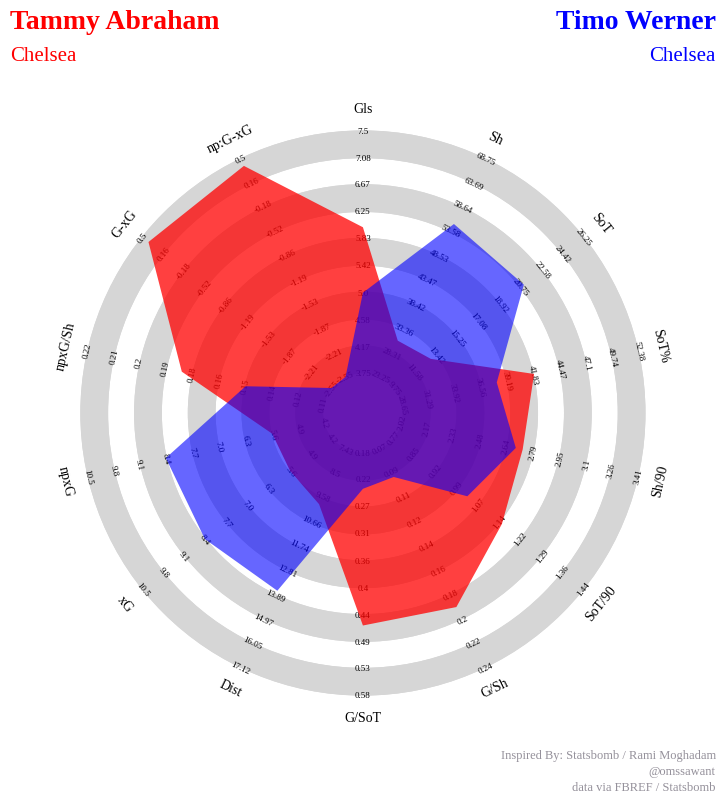

In [ ]:
radar = Radar()

fig,ax = radar.plot_radar(ranges = ranges, params = params , values = values,
                          radar_color=['red','blue'],
                          alphas = [.75,.6], title = title, endnote = endnote,
                          compare = True)